# All-Incident Grouped Cox Model Summary

This notebook fits the grouped Cox PH model (8 CANS domain features + demographics) for **all 8 incident types** and then produces cross-incident summary visualizations:

1. **Concordance index table** — model discrimination per incident type  
2. **Cross-incident HR heatmap** — which CANS domains predict which incidents  
3. **Level vs. change analysis** — does current score or recent deterioration drive risk?  
4. **Profile risk curves** — absolute cumulative risk for low / medium / high CANS profiles  

Functions are imported from `cox_utils.py` and `model_visualizations.py`.

In [5]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

from cox_utils import (
    load_data, cox_incident_table, build_cox_df, fit_cox_model,
    build_level_vs_change_cox_df, plot_level_vs_change_coefs,
    drill_down, plot_profile_risk,
    check_cox_assumptions, DEMO_COLS
)
from Scripts.model_visualizations import (
    plot_cross_incident_heatmap,
    plot_concordance_index_bar
)

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [3]:
dfs, top_n_cols, base_cols, incident_cols_dict, group_cols = load_data()

# All 8 incident categories (keys match build_full_hazard_table naming)
INCIDENT_CATS = [
    'Abuse_CPS_Report',
    'Suicide_Related_Incidents',
    'AWOL_Child_Absense',
    'Behavioral_Incidents',
    'Health_Medical_Incidents',
    'Self_Harm',
    'Placement_Changes',
    'Police_Involvement',
]

DISPLAY_NAMES = {
    'Abuse_CPS_Report':          'Abuse / CPS Report',
    'Suicide_Related_Incidents': 'Suicide Related',
    'AWOL_Child_Absense':        'AWOL / Child Absence',
    'Behavioral_Incidents':      'Behavioral',
    'Health_Medical_Incidents':  'Health / Medical',
    'Self_Harm':                 'Self Harm',
    'Placement_Changes':         'Placement Changes',
    'Police_Involvement':        'Police Involvement',
}

print('Group features:', group_cols)
print('Incident category keys available:', list(incident_cols_dict.keys()))

Found 3 data files. Loading...
Duplicates Removed: 2836
Excluded 591 rows: invalid QuestionKey, missing ChoiceValue, or non-max ChoiceValue within group
1. Initial top_n count: 45
2. Count after removing Index columns: 43
3. Degenerate rows excluded: 48
5. All features have variance.
Group features: ['Caregiver_Support_Needs', 'Internalizing_/_Self-Harm', 'Developmental_&_Sexual_Concerns', 'Externalizing_Behavior', 'Family_&_Social_Functioning', 'Community_&_Strengths', 'Substance_Use_&_Delinquency', 'School_Functioning']
Incident category keys available: ['Abuse_CPS_Report', 'Suicide_Related_Incidents', 'AWOL_Child_Absense', 'Behavioral_Incidents', 'Health_Medical_Incidents', 'Self_Harm', 'Placement_Changes', 'Police_Involvement']


## Fit Grouped Cox Models for All Incident Types

Each model uses the 8 CANS domain aggregate features plus demographic controls.
We collect the fitted model and the Cox DataFrame for downstream analyses.

In [6]:
models = {}          # incident_cat -> CoxPHFitter
cox_dfs = {}         # incident_cat -> cox_df used for fitting
incident_tables = {} # incident_cat -> full incident-related table (for level-vs-change)
event_counts = {}    # incident_cat -> number of events

for cat in INCIDENT_CATS:
    if cat not in incident_cols_dict:
        print(f'[SKIP] {cat} — not in incident_cols_dict')
        continue

    #print(f'\n{'='*60}')
    print(f'Fitting: {DISPLAY_NAMES.get(cat, cat)}')
    print('='*60)

    try:
        table = cox_incident_table(cat, dfs, base_cols, incident_cols_dict)
        cox_df = build_cox_df(table, cat, group_cols)

        n_events = int(cox_df[f'{cat}_event'].sum())
        event_counts[cat] = n_events

        if n_events < 20:
            print(f'[SKIP] Only {n_events} events — too few for reliable Cox estimation')
            continue

        cph = fit_cox_model(cox_df, cat)
        models[cat] = cph
        cox_dfs[cat] = cox_df
        incident_tables[cat] = table

        print(f'Concordance index: {cph.concordance_index_:.4f}')
        display(cph.summary[['coef', 'exp(coef)', 'p', '-log2(p)']].round(4))

    except Exception as e:
        print(f'[ERROR] {cat}: {e}')

Fitting: Abuse / CPS Report
Shape: (3231, 20)
Events: 219
Concordance index: 0.7114


,coef,exp(coef),p,-log2(p)
covariate,,,,
Caregiver_Support_Needs,0.0300,1.0305,0.1200,3.0594
Internalizing_/_Self-Harm,0.0448,1.0459,0.0463,4.4338
Developmental_&_Sexual_Concerns,-0.0149,0.9852,0.7764,0.3652
Externalizing_Behavior,0.0239,1.0242,0.3292,1.6029
Family_&_Social_Functioning,0.0899,1.0940,0.0152,6.0421
Community_&_Strengths,-0.0120,0.9880,0.6997,0.5153
Substance_Use_&_Delinquency,-0.0696,0.9327,0.2489,2.0065
School_Functioning,0.0091,1.0091,0.7697,0.3776
Black,-1.3588,0.2570,0.0001,12.8730


Fitting: Suicide Related
Shape: (3231, 20)
Events: 170
Concordance index: 0.7069


,coef,exp(coef),p,-log2(p)
covariate,,,,
Caregiver_Support_Needs,-0.0405,0.9603,0.1371,2.8663
Internalizing_/_Self-Harm,0.1764,1.1929,0.0000,33.3793
Developmental_&_Sexual_Concerns,-0.0061,0.9939,0.9231,0.1154
Externalizing_Behavior,-0.0192,0.9810,0.5782,0.7904
Family_&_Social_Functioning,0.0037,1.0037,0.9289,0.1064
Community_&_Strengths,-0.0159,0.9842,0.6967,0.5213
Substance_Use_&_Delinquency,-0.1810,0.8345,0.0148,6.0790
School_Functioning,0.0071,1.0072,0.8411,0.2497
Black,-0.3800,0.6839,0.3087,1.6959


Fitting: AWOL / Child Absence
Shape: (3231, 20)
Events: 97
Concordance index: 0.7950


...

,coef,exp(coef),p,-log2(p)
covariate,,,,
Caregiver_Support_Needs,-0.0268,0.9736,0.5392,0.8911
Internalizing_/_Self-Harm,0.0184,1.0185,0.6851,0.5455
Developmental_&_Sexual_Concerns,0.1248,1.1329,0.1546,2.6929
Externalizing_Behavior,-0.0161,0.9840,0.7774,0.3633
Family_&_Social_Functioning,-0.0591,0.9426,0.3566,1.4874
Community_&_Strengths,0.1352,1.1447,0.0077,7.0180
Substance_Use_&_Delinquency,0.0942,1.0988,0.4768,1.0684
School_Functioning,0.0029,1.0029,0.9659,0.0500
Black,0.2160,1.2411,0.8016,0.3191


Fitting: Self Harm
Shape: (3231, 20)
Events: 43
Concordance index: 0.8308


,coef,exp(coef),p,-log2(p)
covariate,,,,
Caregiver_Support_Needs,0.0224,1.0227,0.6233,0.6820
Internalizing_/_Self-Harm,0.2832,1.3273,0.0000,24.3477
Developmental_&_Sexual_Concerns,-0.1131,0.8930,0.3865,1.3716
Externalizing_Behavior,-0.0369,0.9638,0.6019,0.7323
Family_&_Social_Functioning,-0.0912,0.9129,0.2161,2.2104
Community_&_Strengths,0.0413,1.0422,0.4091,1.2896
Substance_Use_&_Delinquency,-0.0001,0.9999,0.9993,0.0010
School_Functioning,0.0472,1.0483,0.4846,1.0453
Black,0.4467,1.5631,0.5560,0.8469


Fitting: Placement Changes
Shape: (3231, 20)
Events: 22
[ERROR] Placement_Changes: Convergence halted due to matrix inversion problems. Suspicion is high collinearity. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-modelMatrix is singular.
Fitting: Police Involvement
Shape: (3231, 20)
Events: 116
Concordance index: 0.7276


,coef,exp(coef),p,-log2(p)
covariate,,,,
Caregiver_Support_Needs,-0.0270,0.9734,0.2127,2.2331
Internalizing_/_Self-Harm,-0.0269,0.9735,0.3920,1.3510
Developmental_&_Sexual_Concerns,-0.0646,0.9374,0.2602,1.9421
Externalizing_Behavior,0.0994,1.1045,0.0017,9.2229
Family_&_Social_Functioning,0.0375,1.0382,0.3750,1.4152
Community_&_Strengths,0.0445,1.0455,0.2684,1.8973
Substance_Use_&_Delinquency,0.1188,1.1261,0.0520,4.2650
School_Functioning,0.0262,1.0266,0.4739,1.0773
Black,0.1678,1.1828,0.6508,0.6197


## Model Discrimination: Concordance Index

Harrell's C-statistic (concordance index) measures how well each model ranks individuals by their true risk order. 0.5 = random, 1.0 = perfect.

**Benchmark**: C > 0.6 is generally considered acceptable; C > 0.7 is good for clinical risk models.

       Incident Type  Events Concordance Index
  Abuse / CPS Report     219            0.7114
     Suicide Related     170            0.7069
AWOL / Child Absence      97            0.7950
          Behavioral      89            0.6380
    Health / Medical      52            0.7327
           Self Harm      43            0.8308
  Police Involvement     116            0.7276


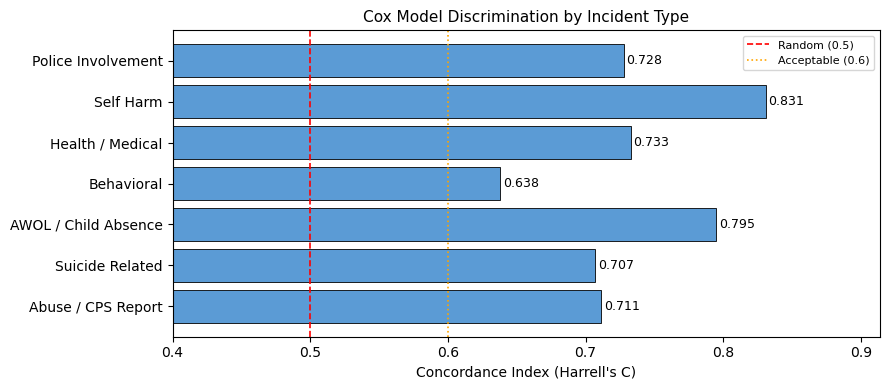

In [8]:
concordance = {cat: cph.concordance_index_ for cat, cph in models.items()}

concordance_df = pd.DataFrame({
    'Incident Type': [DISPLAY_NAMES.get(k, k) for k in concordance],
    'Events': [event_counts.get(k, '-') for k in concordance],
    'Concordance Index': [f'{v:.4f}' for v in concordance.values()]
})
print(concordance_df.to_string(index=False))

plot_concordance_index_bar(concordance, display_names=DISPLAY_NAMES)

## Cross-Incident CANS HR Heatmap

Each cell shows the log hazard ratio for one CANS domain feature predicting one incident type.

- **Red** = increased incident risk with higher CANS scores in that domain  
- **Green** = protective (lower risk with higher scores — uncommon but can reflect measurement context)  
- **★** = statistically significant at p < 0.05  

This reveals which CANS domains are **broadly predictive** across all incident types vs. **incident-specific** risk factors.

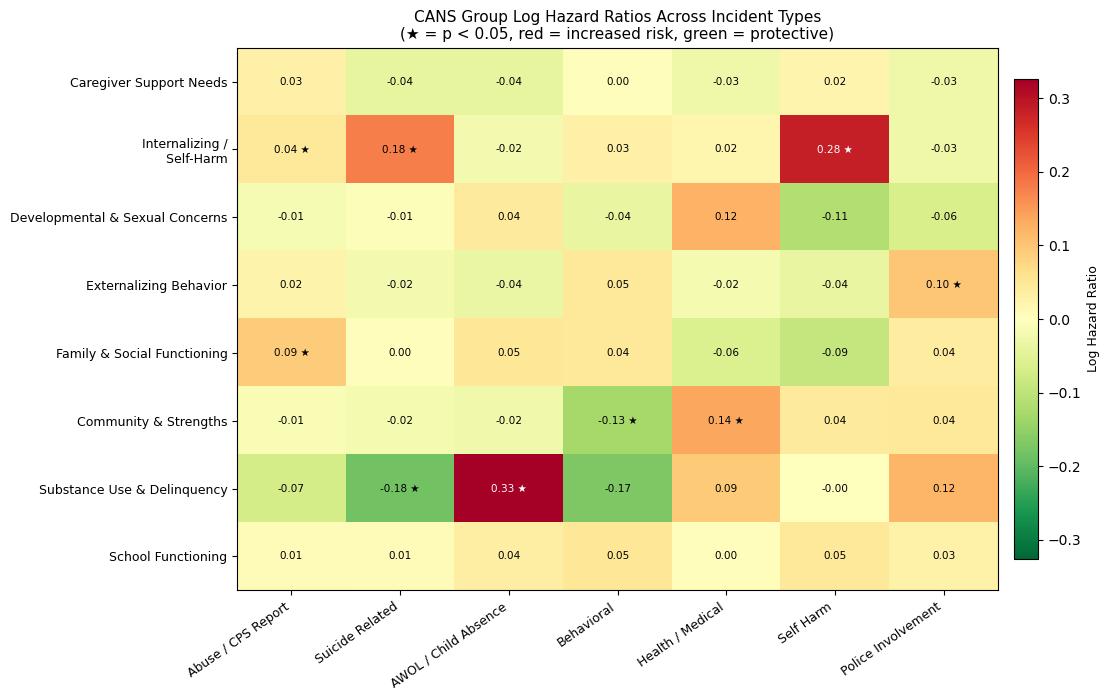

In [9]:
coef_df, pval_df = plot_cross_incident_heatmap(
    models,
    feature_cols=group_cols,
    display_names=DISPLAY_NAMES,
    show_significance=True
)

### Interpreting the Heatmap

Look for:
- **Row patterns**: A domain with consistently red cells is a broad risk factor (e.g. `Internalizing / Self-Harm` likely red for suicide, self-harm, and possibly behavioral incidents).  
- **Column patterns**: An incident type with mostly grey / non-significant cells means CANS domain scores are weak predictors for that incident type — demographics and prior count likely dominate.  
- **Surprising greens**: Any domain showing strong protective association (green ★) deserves interpretation — it may reflect scale direction or confounding by treatment engagement.

## Level vs. Change Analysis

The standard Cox model captures the *current level* of each CANS domain score. But is it the absolute score that matters, or **recent deterioration**?

For each incident type we fit a joint model with both:
- **Level**: current domain aggregate score  
- **Delta**: change from the previous assessment (positive = worsening)

Significant delta effects tell us that *trajectory matters beyond the current snapshot* — clinically important because it can trigger earlier intervention.


--- Level vs. Change: Abuse / CPS Report ---
Shape: (3231, 26)
Events: 219


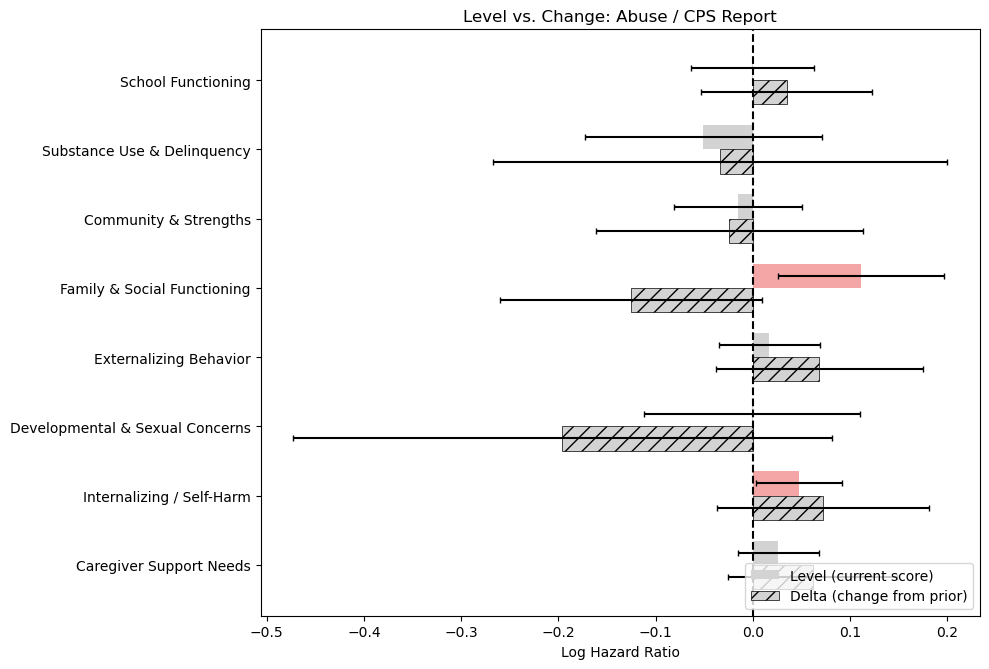


--- Level vs. Change: Suicide Related ---
Shape: (3231, 26)
Events: 170


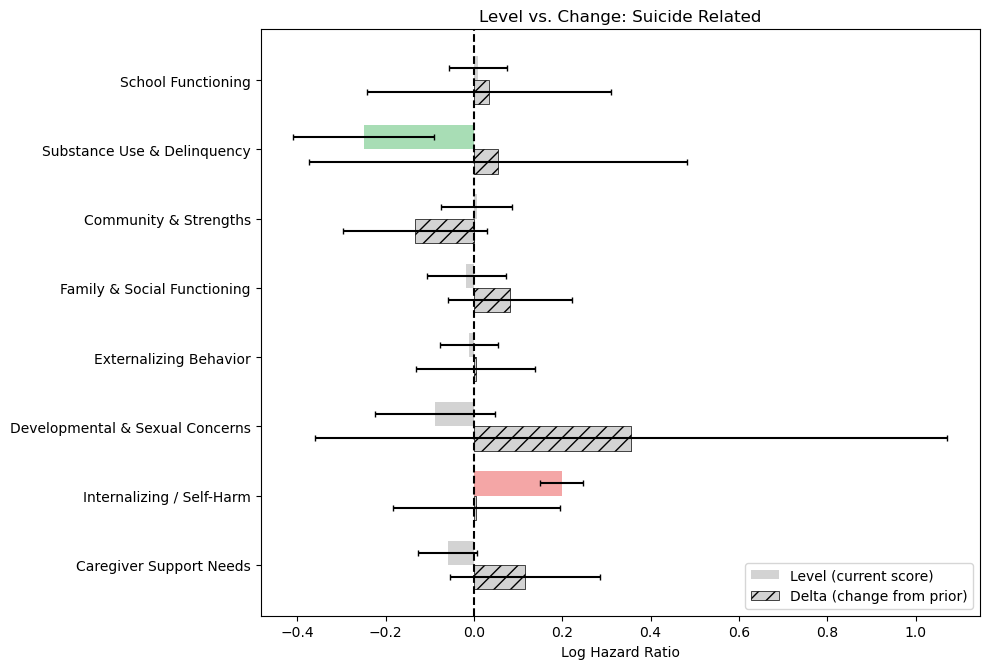


--- Level vs. Change: AWOL / Child Absence ---
Shape: (3231, 26)
Events: 97


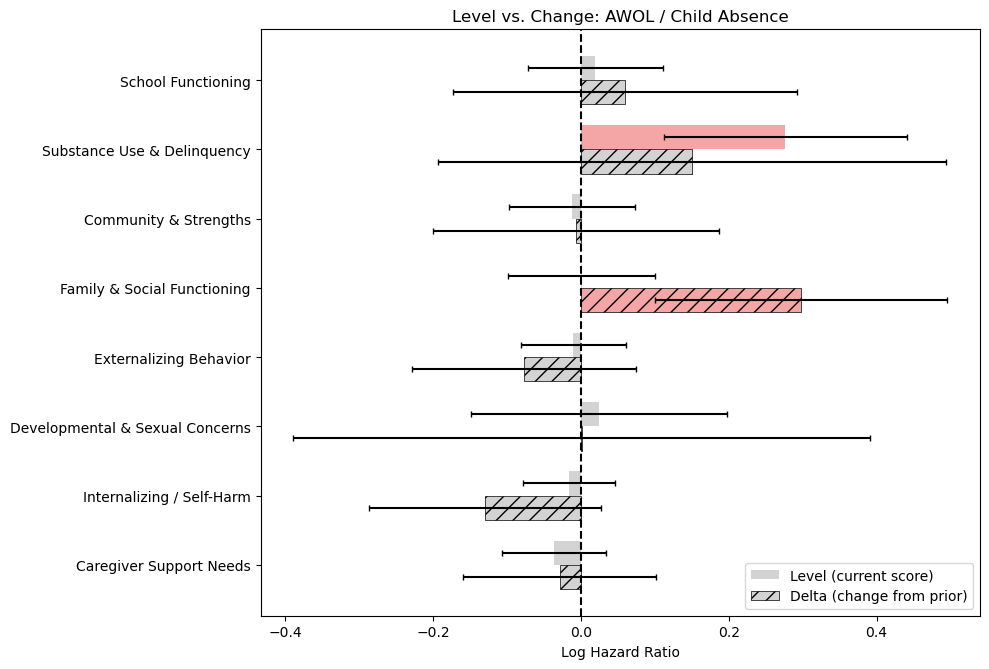


--- Level vs. Change: Behavioral ---
Shape: (3231, 26)
Events: 89


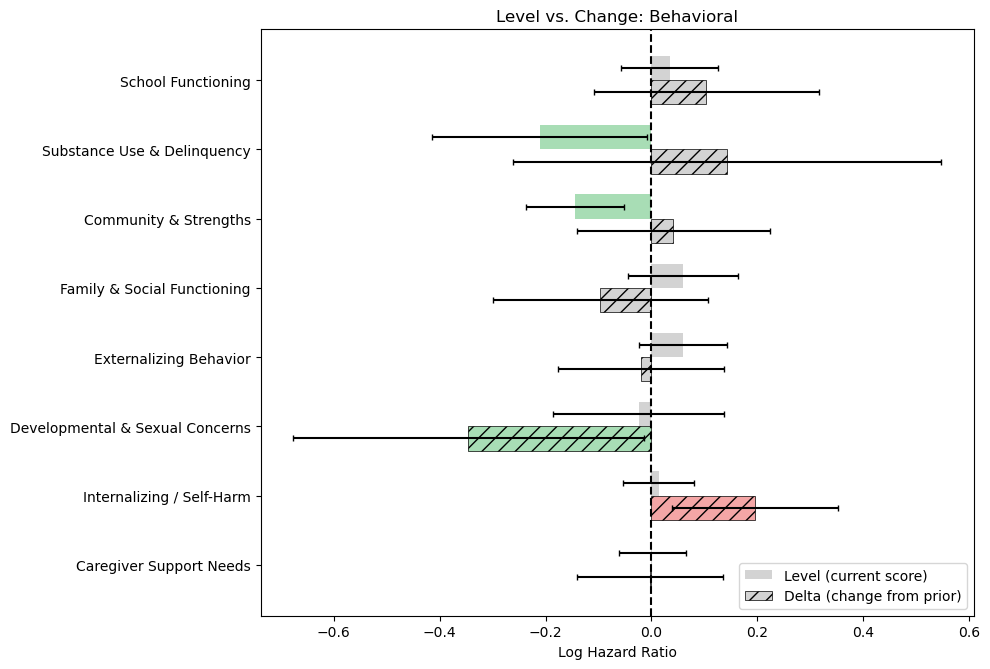


--- Level vs. Change: Health / Medical ---
Shape: (3231, 26)
Events: 52


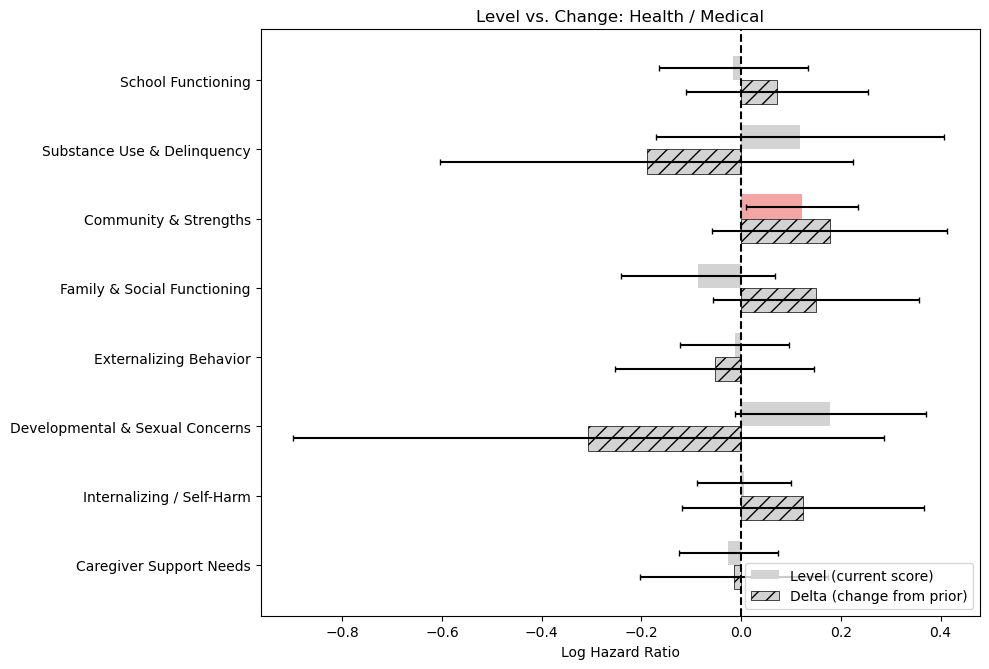


--- Level vs. Change: Self Harm ---
Shape: (3231, 26)
Events: 43


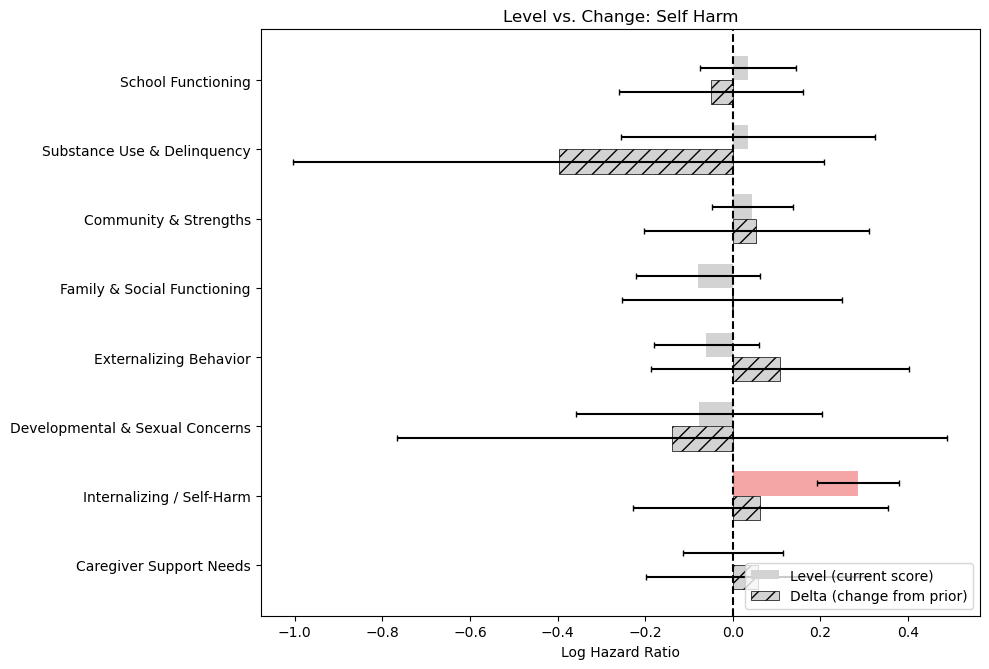


--- Level vs. Change: Police Involvement ---
Shape: (3231, 26)
Events: 116


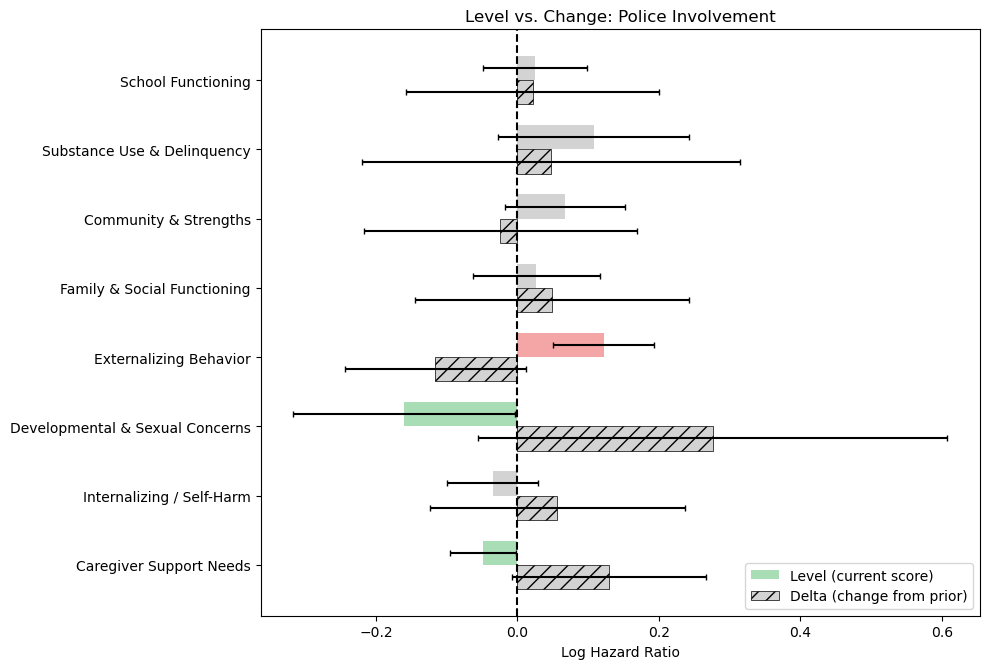

In [10]:
lvc_models = {}     # incident_cat -> fitted level-vs-change CoxPHFitter
lvc_pairs = {}      # incident_cat -> feature_pairs list

for cat in models:  # only attempt cats with successful group model
    print(f'\n--- Level vs. Change: {DISPLAY_NAMES.get(cat, cat)} ---')
    try:
        table = incident_tables[cat]
        lvc_df, feature_pairs = build_level_vs_change_cox_df(
            table, cat, group_cols
        )
        cph_lvc = fit_cox_model(lvc_df, cat)
        lvc_models[cat] = cph_lvc
        lvc_pairs[cat] = feature_pairs

        plot_level_vs_change_coefs(
            cph_lvc, feature_pairs,
            title=f'Level vs. Change: {DISPLAY_NAMES.get(cat, cat)}'
        )
    except Exception as e:
        print(f'[ERROR] {cat}: {e}')

### Interpreting Level vs. Change Plots

Each row shows two bars for the same CANS domain:
- **Solid bar (level)**: effect of the current score  
- **Hatched bar (delta)**: effect of the change since the last assessment  

Colored bars are statistically significant (p < 0.05); grey bars are not.

Key patterns to look for:
- **Only level significant**: current severity drives risk, trajectory doesn't add information  
- **Only delta significant**: change (deterioration/improvement) matters more than absolute level  
- **Both significant, same direction**: additive signal — current level and recent worsening both increase risk  
- **Opposite directions**: complex pattern — high baseline may co-occur with improvement (treatment effect)

## Proportional Hazards Assumption Checks

The Cox model assumes hazard ratios are **constant over time** (proportional hazards). We check this using complementary log-log plots for each CANS domain covariate. Parallel lines support the assumption; crossing or strongly diverging lines indicate a violation.

Note: lifelines' built-in `check_assumptions()` does not support left-truncated (delayed-entry) data, so we use stratified Kaplan-Meier plots instead.


=== PH Check: Abuse / CPS Report ===
Concordance index: 0.7114


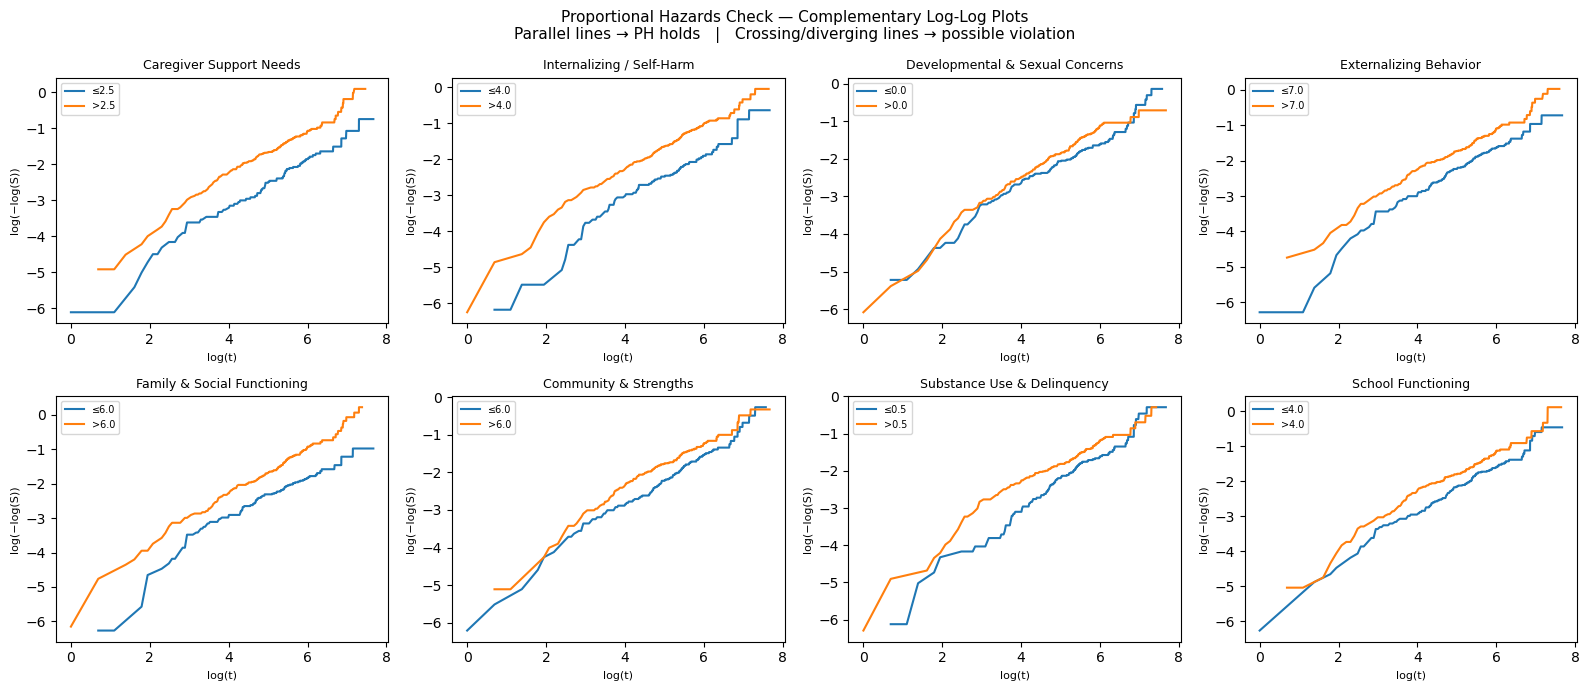

Concordance Index: 0.7114  (0.5 = random, 1.0 = perfect discrimination)

=== PH Check: Suicide Related ===
Concordance index: 0.7069


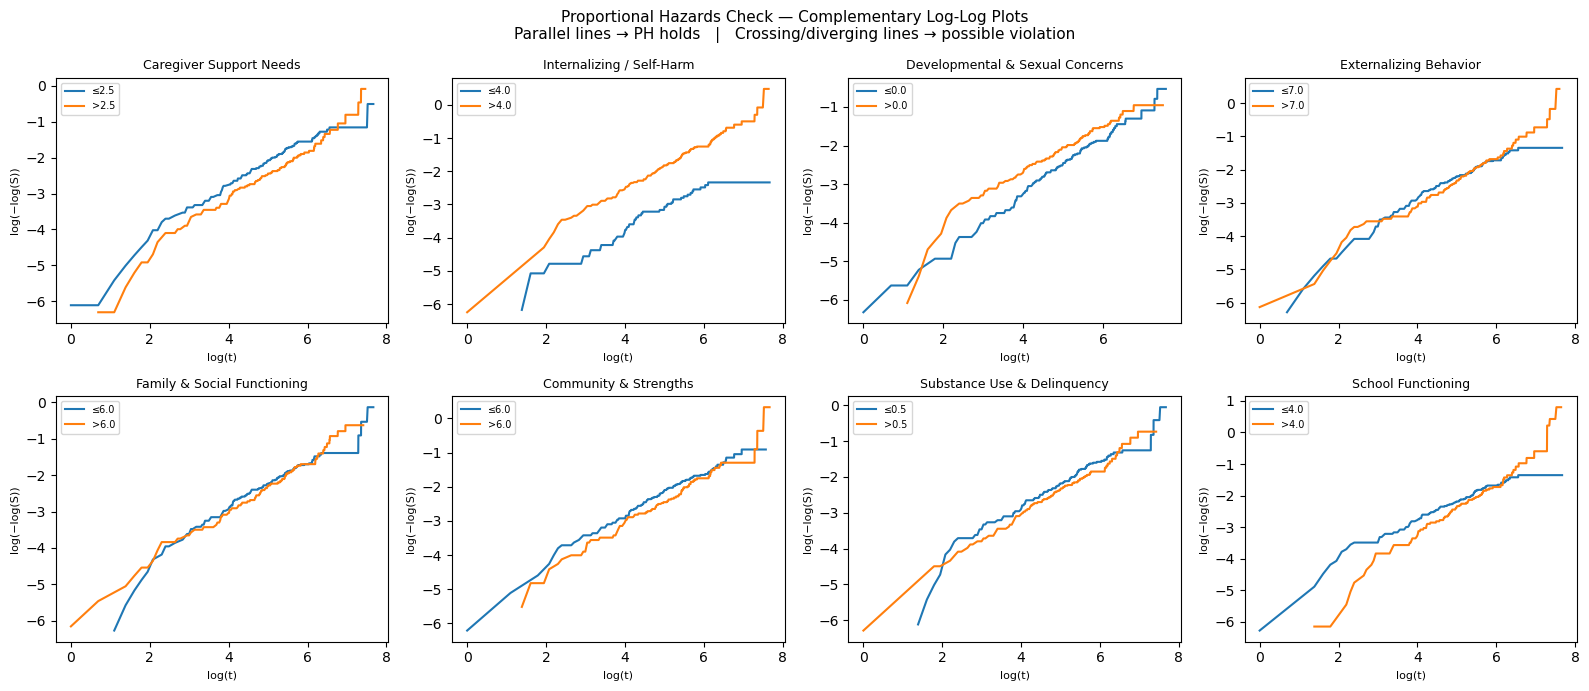

Concordance Index: 0.7069  (0.5 = random, 1.0 = perfect discrimination)

=== PH Check: AWOL / Child Absence ===
Concordance index: 0.7950


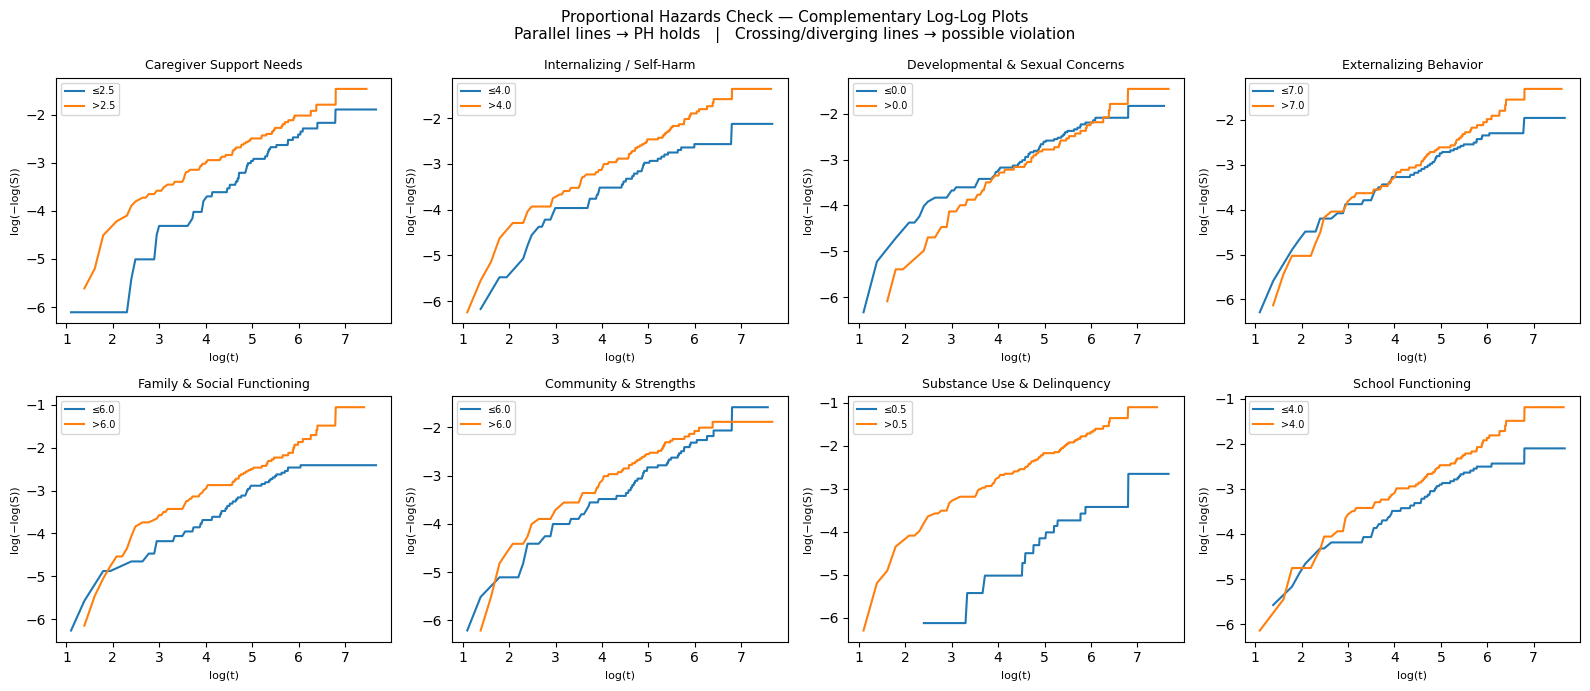

Concordance Index: 0.7950  (0.5 = random, 1.0 = perfect discrimination)

=== PH Check: Behavioral ===
Concordance index: 0.6380


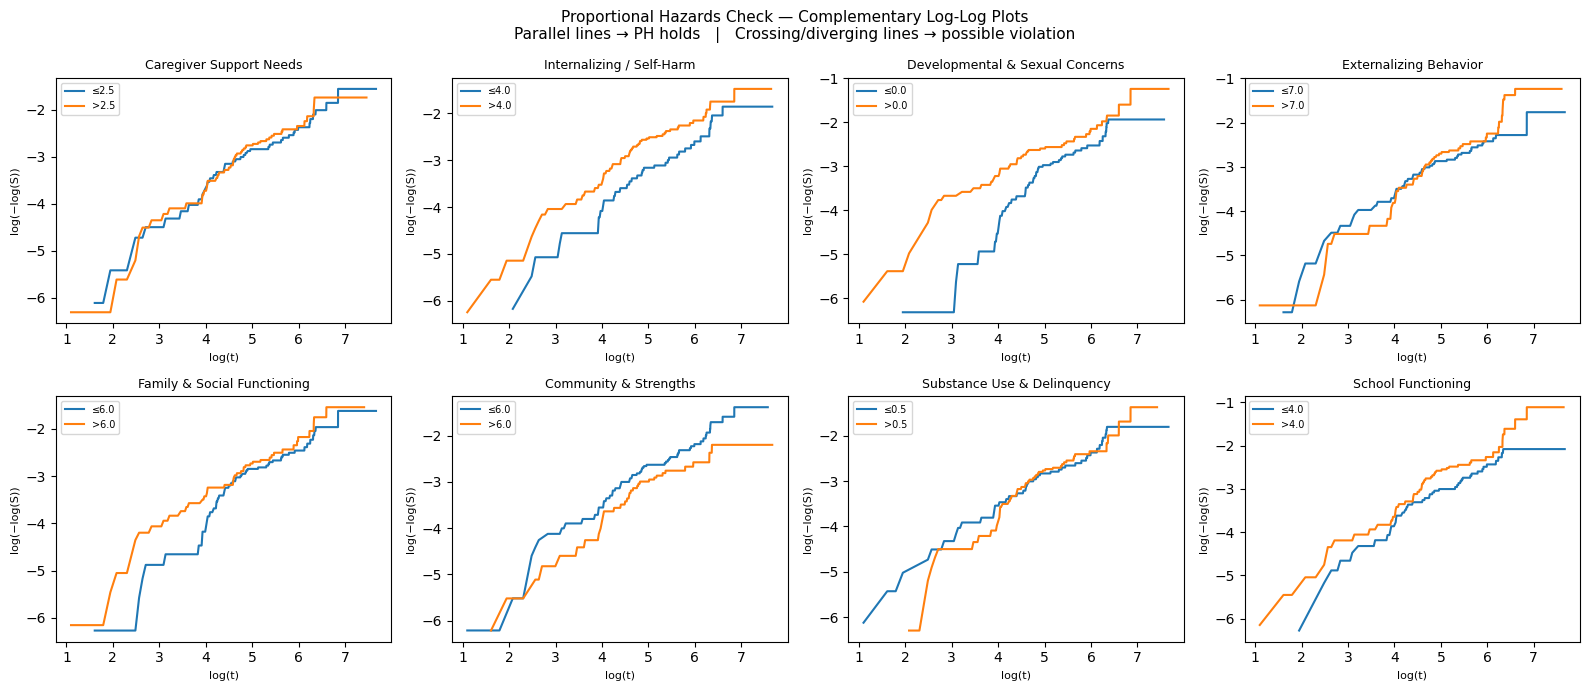

Concordance Index: 0.6380  (0.5 = random, 1.0 = perfect discrimination)

=== PH Check: Health / Medical ===
Concordance index: 0.7327


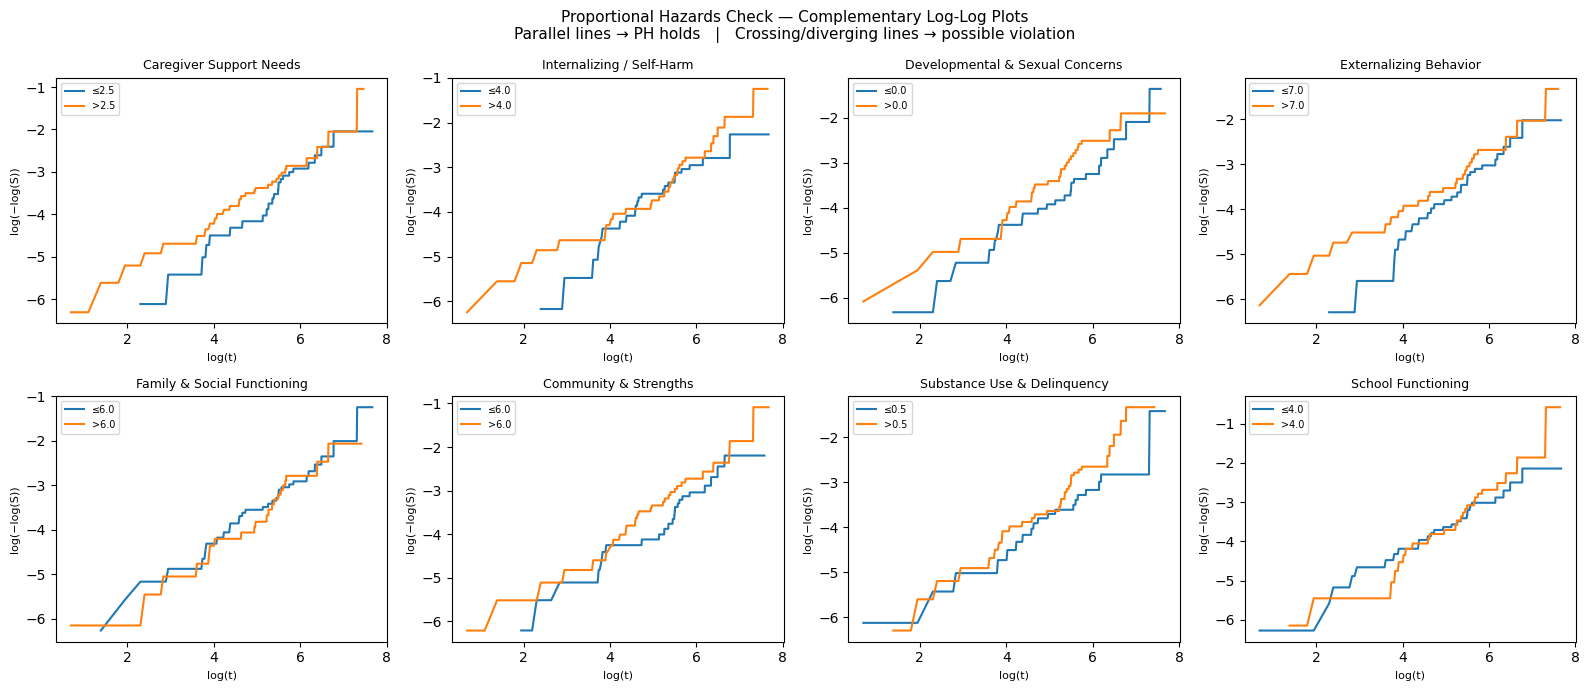

Concordance Index: 0.7327  (0.5 = random, 1.0 = perfect discrimination)

=== PH Check: Self Harm ===
Concordance index: 0.8308


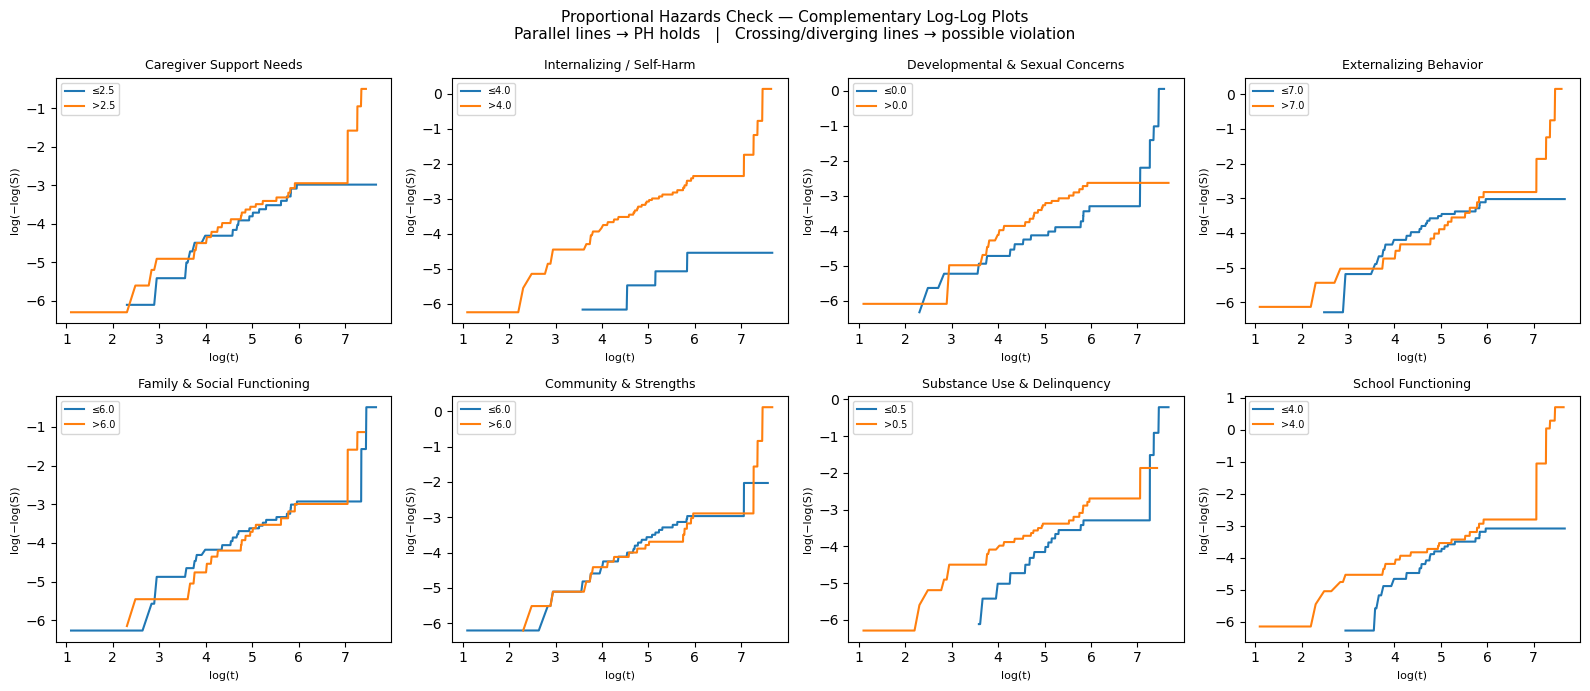

Concordance Index: 0.8308  (0.5 = random, 1.0 = perfect discrimination)

=== PH Check: Police Involvement ===
Concordance index: 0.7276


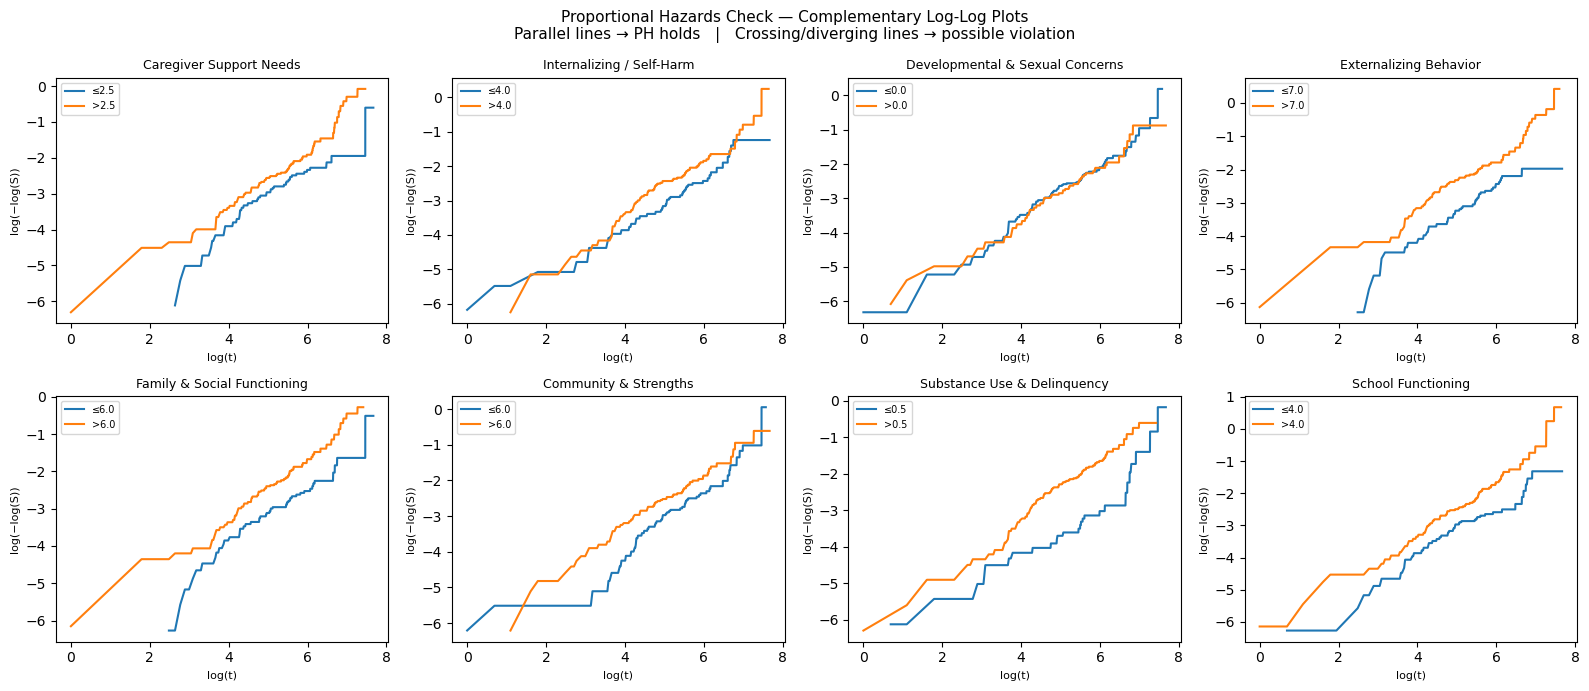

Concordance Index: 0.7276  (0.5 = random, 1.0 = perfect discrimination)


In [11]:
for cat, cph in models.items():
    print(f'\n=== PH Check: {DISPLAY_NAMES.get(cat, cat)} ===')
    print(f'Concordance index: {cph.concordance_index_:.4f}')
    check_cox_assumptions(cph, cox_dfs[cat], covariates=group_cols)

## Profile Risk Curves

For each incident type we use the drill-down model (individual CANS items within the highest-risk group) to plot cumulative incident probability over 90 days for three risk profiles:

- **Low**: key items all scored 0 (no need / strength present)  
- **Medium**: key items scored 1–2  
- **High**: key items scored 3 (serious / pervasive need)  

Profiles are constructed per-incident-type based on the top items identified in the drill-down step.


=== Profile Risk: Abuse / CPS Report ===
Top risk group: Family_&_Social_Functioning
Items in group: ['Family Function', 'Social Functioning', 'Living Situation', 'Family Strengths', 'Interpersonal']


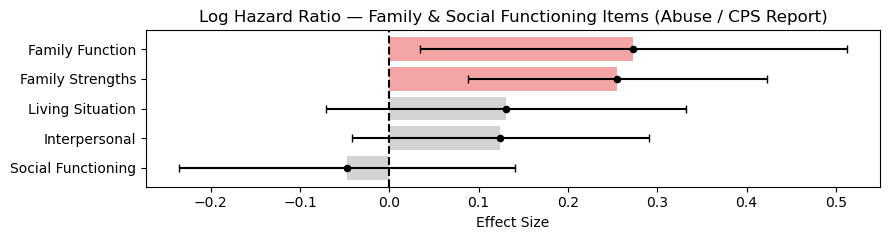


Top 3 most impactful CANS scores:
  Family Function: coef = 0.2733, p = 2.4878e-02
  Family Strengths: coef = 0.2553, p = 2.8440e-03
  Living Situation: coef = 0.1306, p = 2.0465e-01


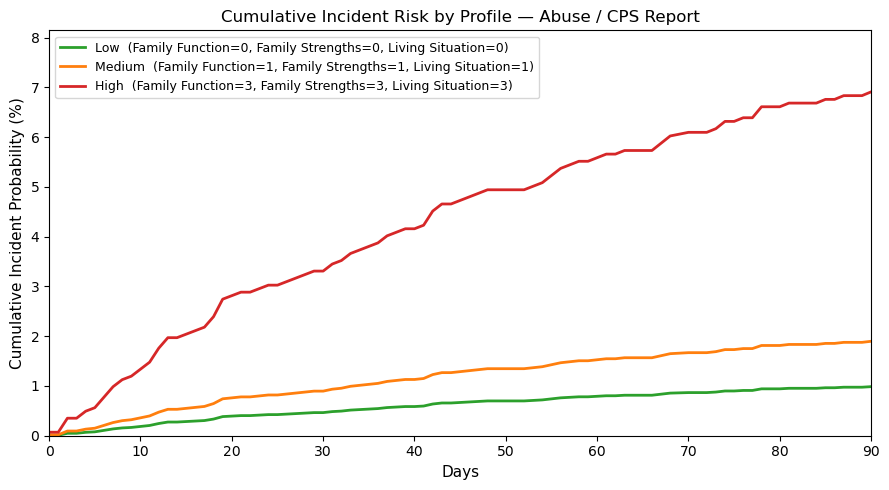


=== Profile Risk: Suicide Related ===
Top risk group: Internalizing_/_Self-Harm
Items in group: ['Sleep', 'Anxiety', 'Adjustment To Trauma', 'Depression', 'Other Self Harm (Recklessness)', 'Non-Suicidal Self Injurious Behavior', 'Suicide Risk']


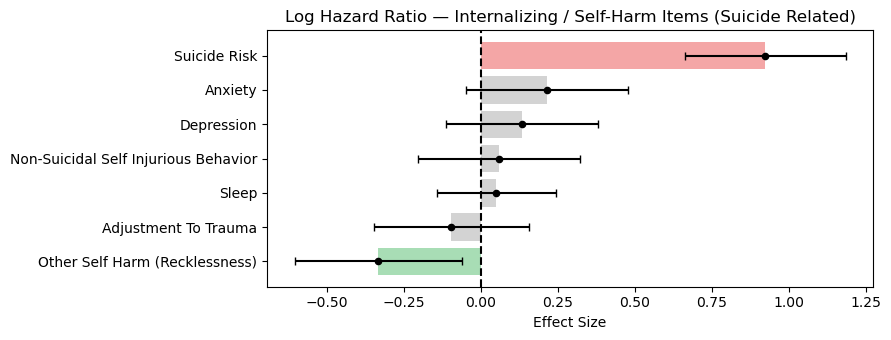


Top 3 most impactful CANS scores:
  Suicide Risk: coef = 0.9235, p = 4.3820e-12
  Other Self Harm (Recklessness): coef = -0.3323, p = 1.6480e-02
  Anxiety: coef = 0.2153, p = 1.0775e-01


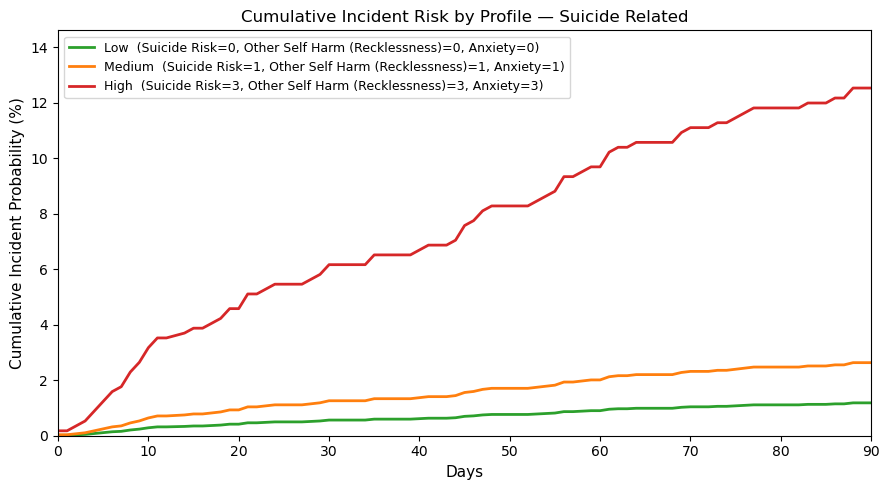


=== Profile Risk: AWOL / Child Absence ===
Top risk group: Substance_Use_&_Delinquency
Items in group: ['Substance Use', 'Runaway', 'Delinquent Behavior']


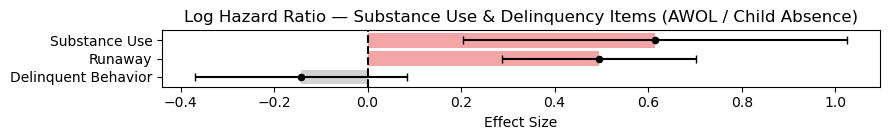


Top 3 most impactful CANS scores:
  Substance Use: coef = 0.6145, p = 3.4097e-03
  Runaway: coef = 0.4957, p = 2.8215e-06
  Delinquent Behavior: coef = -0.1423, p = 2.2017e-01


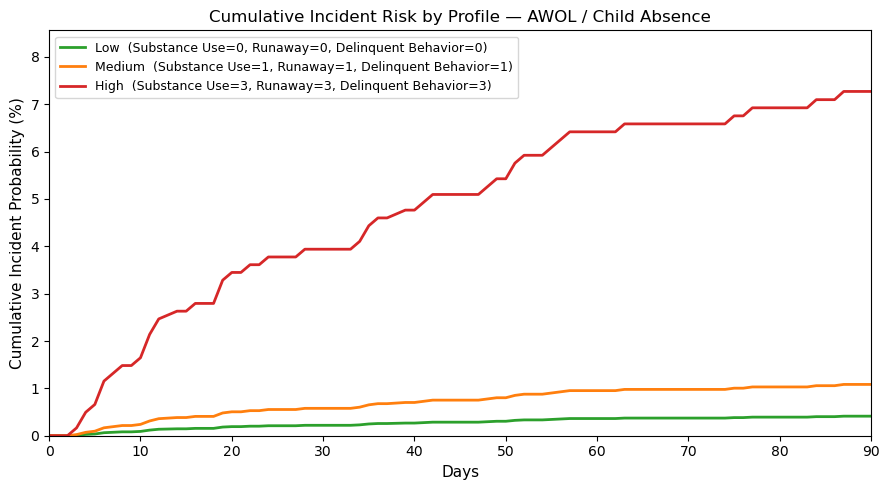


=== Profile Risk: Behavioral ===
Top risk group: School_Functioning
Items in group: ['School Attendance', 'School Behavior', 'School Achievement', 'Educational']


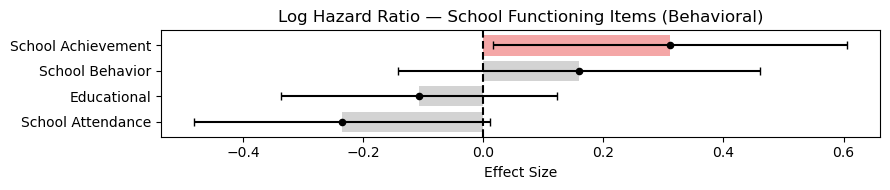


Top 3 most impactful CANS scores:
  School Achievement: coef = 0.3114, p = 3.8418e-02
  School Attendance: coef = -0.2356, p = 6.0933e-02
  School Behavior: coef = 0.1596, p = 2.9942e-01


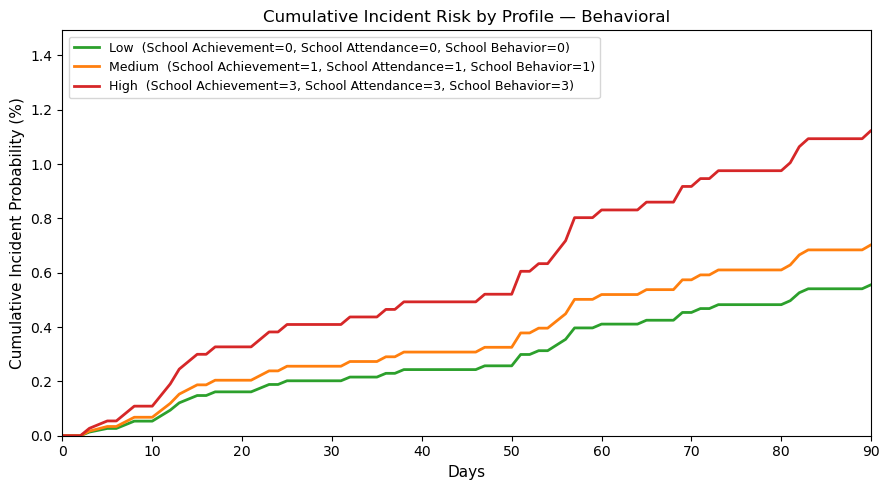


=== Profile Risk: Health / Medical ===
Top risk group: Community_&_Strengths
Items in group: ['Talents/Interests', 'Natural Supports', 'Community Life/Connection', 'Spiritual/Religious']


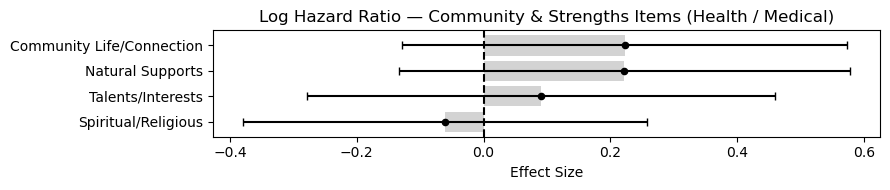


Top 3 most impactful CANS scores:
  Community Life/Connection: coef = 0.2223, p = 2.1473e-01
  Natural Supports: coef = 0.2220, p = 2.2067e-01
  Talents/Interests: coef = 0.0904, p = 6.3046e-01


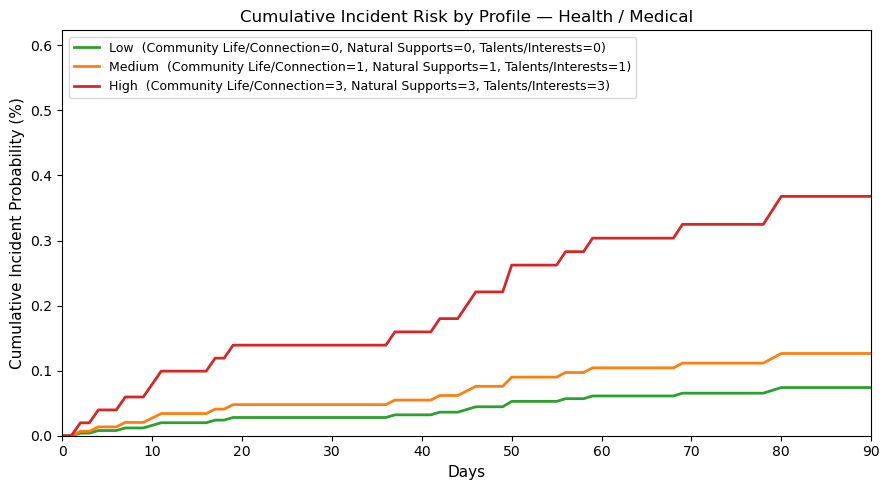


=== Profile Risk: Self Harm ===
Top risk group: Internalizing_/_Self-Harm
Items in group: ['Sleep', 'Anxiety', 'Adjustment To Trauma', 'Depression', 'Other Self Harm (Recklessness)', 'Non-Suicidal Self Injurious Behavior', 'Suicide Risk']


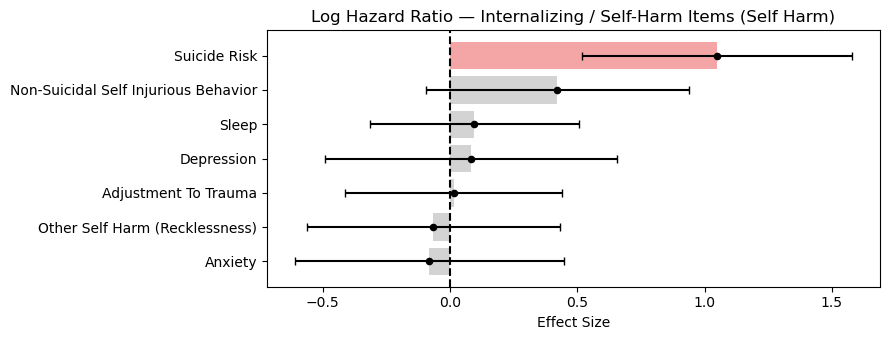


Top 3 most impactful CANS scores:
  Suicide Risk: coef = 1.0496, p = 1.0401e-04
  Non-Suicidal Self Injurious Behavior: coef = 0.4212, p = 1.1040e-01
  Sleep: coef = 0.0953, p = 6.4942e-01


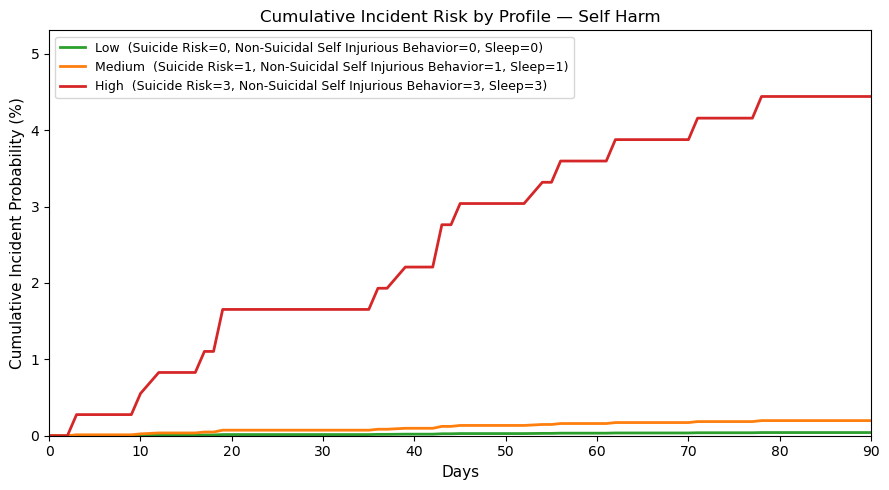


=== Profile Risk: Police Involvement ===
Top risk group: Substance_Use_&_Delinquency
Items in group: ['Substance Use', 'Runaway', 'Delinquent Behavior']


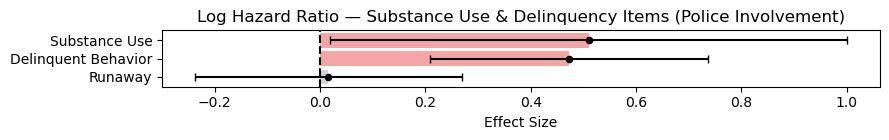


Top 3 most impactful CANS scores:
  Substance Use: coef = 0.5098, p = 4.2059e-02
  Delinquent Behavior: coef = 0.4730, p = 4.3862e-04
  Runaway: coef = 0.0154, p = 9.0494e-01


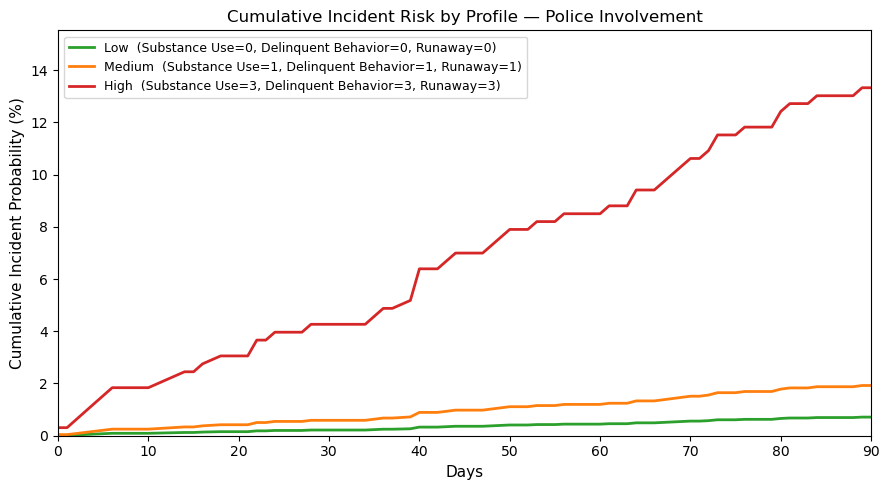

In [12]:
for cat in models:
    print(f'\n=== Profile Risk: {DISPLAY_NAMES.get(cat, cat)} ===')
    try:
        cph = models[cat]
        table = incident_tables[cat]

        cph_drill, drill_df, top_items = drill_down(
            cph, group_cols, table, cat, DISPLAY_NAMES.get(cat, cat),
            demo_cols=DEMO_COLS
        )

        if len(top_items) == 0:
            print('No top items found — skipping profile risk.')
            continue

        # Build profiles using the top item(s): low=0, medium=1, high=3
        low_profile    = {item: 0 for item in top_items}
        medium_profile = {item: 1 for item in top_items}
        high_profile   = {item: 3 for item in top_items}

        plot_profile_risk(
            cph_drill, drill_df, cat,
            profiles={'Low': low_profile, 'Medium': medium_profile, 'High': high_profile},
            incident_display=DISPLAY_NAMES.get(cat, cat),
            time_horizon=90
        )
    except Exception as e:
        print(f'[ERROR] {cat}: {e}')

## Summary Table: Key Results Across All Incident Types

Aggregates the most significant CANS domain finding per incident type alongside concordance index.

In [13]:
rows = []
for cat, cph in models.items():
    group_summary = cph.summary.loc[
        [c for c in group_cols if c in cph.summary.index]
    ]
    sig_groups = group_summary[group_summary['p'] < 0.05]

    if len(sig_groups) > 0:
        top = sig_groups['coef'].abs().idxmax()
        top_coef = sig_groups.loc[top, 'coef']
        top_p    = sig_groups.loc[top, 'p']
        direction = 'Risk ↑' if top_coef > 0 else 'Protective ↓'
        top_str = f'{top.replace("_", " ")} ({direction}, coef={top_coef:.3f}, p={top_p:.4f})'
    else:
        top_str = 'No significant CANS group effects'

    rows.append({
        'Incident Type':       DISPLAY_NAMES.get(cat, cat),
        'N Events':            event_counts.get(cat, '-'),
        'Concordance Index':   f"{cph.concordance_index_:.4f}",
        'Sig. CANS Groups':    len(sig_groups),
        'Top CANS Signal':     top_str,
    })

summary_df = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', 80)
display(summary_df)

,Incident Type,N Events,Concordance Index,Sig. CANS Groups,Top CANS Signal
0,Abuse / CPS Report,219,0.7114,2,"Family & Social Functioning (Risk ↑, coef=0.090, p=0.0152)"
1,Suicide Related,170,0.7069,2,"Substance Use & Delinquency (Protective ↓, coef=-0.181, p=0.0148)"
2,AWOL / Child Absence,97,0.7950,1,"Substance Use & Delinquency (Risk ↑, coef=0.326, p=0.0001)"
3,Behavioral,89,0.6380,1,"Community & Strengths (Protective ↓, coef=-0.130, p=0.0029)"
4,Health / Medical,52,0.7327,1,"Community & Strengths (Risk ↑, coef=0.135, p=0.0077)"
5,Self Harm,43,0.8308,1,"Internalizing / Self-Harm (Risk ↑, coef=0.283, p=0.0000)"
6,Police Involvement,116,0.7276,1,"Externalizing Behavior (Risk ↑, coef=0.099, p=0.0017)"
